In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


def iqr_cal(data,k=3): # if k = 3 then it only detectes extreme outliers, k= 1.5 doesn't
    q1, q3 = data.quantile(0.25), data.quantile(0.75) # The 25 percent and 75 percent of the data
    iqr =  q3 - q1
    return q1 - k * iqr, q3+k *iqr
#TASK7
def clean_data(data):
  # Enter the path to access data
  path = input("Whats the Datas' path?")

  #TASK1
  df = pd.read_csv(path)
  df.head()

  #TASK2
  print(df.shape)

  #TASK3
  df.info()
  print("Check the types, if there are any wrong ones CHANGE them")

  #TASK4
  notdetect = ["N\\A","NA","not reported", "unknown", "?"]
  print("\nNUM OF NULL IN EACH COL\n-------------------------------------")
  for i in df:
    print(f"The num of nulls in the col {i} is {df[i].isna().sum()}")
  df = df.drop(["Alley", "Mas Vnr Type", "Mas Vnr Area","Pool QC", "Misc Feature", "Fence", "Fireplace Qu", "Lot Frontage", "Pool Area", "Screen Porch", "3Ssn Porch", "Misc Val", "Enclosed Porch"], axis=1) #These are the cols that are mostly null, i removed them so the code can work, and so does the user of the func should
  df = df.dropna(axis="rows")

  #TASK5
  print(f"\n\nNum of dups is {df.duplicated().sum()}")

  #TASK6
  targetcol = "SalePrice"
  lower, upper = iqr_cal(df[targetcol])
  print("\n\nThe target Vars BoxPlot:")
  sns.boxplot(data =df, x =df[targetcol])
  plt.show()
  print("\n\nIts Values above the 99%")
  for i in df[targetcol]:
    if i > df[targetcol].quantile(0.99):
      print(i)
  df[f"{targetcol}Capped"] = df[targetcol].clip(lower=lower, upper=upper)
  print("\n\nThe values after capping:")
  for i in df[f"{targetcol}Capped"]:
    if i > df[f"{targetcol}Capped"].quantile(0.99):
      print(i)


















In [2]:
#TASK 1
df = pd.read_csv("/content/AmesHousing.csv") # Read the dataset
df.head()# print the first 5

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [3]:
#TASK 2
print(df.shape) # (2930, 82)

(2930, 82)


In [4]:
#TASK4
#I put this one before Task 3 because it can't run without it
#Droping Cols
print("----------Num Of Nulls-------")
print(df.isna().sum())
df = df.drop(["Alley", "Mas Vnr Type", "Mas Vnr Area","Pool QC", "Misc Feature", "Fence", "Fireplace Qu", "Lot Frontage", "Pool Area", "Screen Porch", "3Ssn Porch", "Misc Val", "Enclosed Porch"], axis=1) #These cols are mostly Nulls, Also they aren't so important
#Detection:
notdetect = ["N\\A","NA","not reported", "unknown", "?"] # the unknown nulls to pandas
df = df.replace(notdetect, np.nan) # replacs the nulls unknown to pandas to the known
df = df.dropna() # drops rows if their is nan in it

----------Num Of Nulls-------
Order               0
PID                 0
MS SubClass         0
MS Zoning           0
Lot Frontage      490
                 ... 
Mo Sold             0
Yr Sold             0
Sale Type           0
Sale Condition      0
SalePrice           0
Length: 82, dtype: int64


In [5]:
#TASK 3
df.info()
df["Bsmt Full Bath"] = df["Bsmt Full Bath"].astype(int)
df["Bsmt Half Bath"] = df["Bsmt Half Bath"].astype(int)
#I have changed these 2 cols to int from float

<class 'pandas.core.frame.DataFrame'>
Index: 2700 entries, 0 to 2929
Data columns (total 69 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2700 non-null   int64  
 1   PID              2700 non-null   int64  
 2   MS SubClass      2700 non-null   int64  
 3   MS Zoning        2700 non-null   object 
 4   Lot Area         2700 non-null   int64  
 5   Street           2700 non-null   object 
 6   Lot Shape        2700 non-null   object 
 7   Land Contour     2700 non-null   object 
 8   Utilities        2700 non-null   object 
 9   Lot Config       2700 non-null   object 
 10  Land Slope       2700 non-null   object 
 11  Neighborhood     2700 non-null   object 
 12  Condition 1      2700 non-null   object 
 13  Condition 2      2700 non-null   object 
 14  Bldg Type        2700 non-null   object 
 15  House Style      2700 non-null   object 
 16  Overall Qual     2700 non-null   int64  
 17  Overall Cond     27

In [6]:
#TASK 5
print(df.duplicated().sum()) #No dups


0


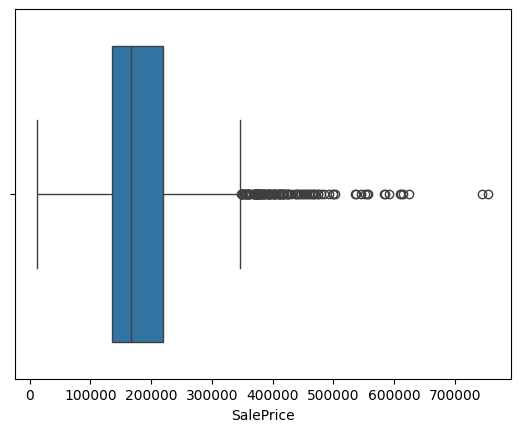

The 99% is 462029.9999999993
The Values above the 99%:
538000
611657
500000
501837
485000
555000
610000
582933
552000
468000
615000
475000
591587
492000
479069
500067
745000
466500
755000
545224
556581
535000
470000
465000
625000
584500
475000
The values have been Capped


In [7]:

#TASK 6
sns.boxplot(data =df, x ="SalePrice") # Gives a boxplot about the saleprice
plt.show() #Shows it


lower, upper = iqr_cal(df["SalePrice"]) #iqr_cal at the top
over99 = df["SalePrice"].quantile(0.99) #To help see the values above the 99 percentile
print(f"The 99% is {over99}")
print("The Values above the 99%:")
for i in df["SalePrice"]:
  if i > over99:
    print(i)


df["SalePriceCapped"] = df["SalePrice"].clip(lower=lower, upper=upper) # To cap the too big or too small values
print("The values have been Capped")




In [8]:
#The Three checks
print("\n\n\n-----------------THE THREE CHECKS--------------------")
c1=0
c2=0
for i in df:
  if df[i].isna().sum()>=1:
    c1+=1
    print(f"THERE IS A NULL IN THE COL: {i}")
if c1==0:
    print("CHECK NUMBER ONE!\n(No nulls)") #The first check is that there isn't any nulls
for i in df["SalePrice"]:
  if i <= 0 :
    c2+=1
    print("THERE IS A NEGATIVE IN SALEPRICE")
if c2 == 0:
    print("CHECK NUMBER TWO!\n(No negatives)") # The second check is that there isn't any negative values
print("CHECK NUMBER THREE!\n(I only dropped the 6 cols above)") # The third check is that there is the correct num of cols




-----------------THE THREE CHECKS--------------------
CHECK NUMBER ONE!
(No nulls)
CHECK NUMBER TWO!
(No negatives)
CHECK NUMBER THREE!
(I only dropped the 6 cols above)
